# DATA 620 Project 1

In [26]:
from pathlib import Path


# Walk up from cwd until we find the project1 directory
def find_project_dir(name="project1") -> Path:
    for parent in [Path.cwd(), *Path.cwd().parents]:
        candidate = parent / name
        if candidate.is_dir():
            return candidate
    raise FileNotFoundError(f"Could not find '{name}' directory")


PROJECT_DIR = find_project_dir()

## Introduction

For our project, we've taken a Spotify dataset made available on [Kaggle.com by Maharshi Pandya](https://www.kaggle.com/datasets/maharshipandya/-spotify-tracks-dataset) and used it to create a network of music.

We processed the data such that our network has the below characteristics;

- Each of artist, track, and genre is its own node type
- Edges connect artist nodes to track nodes to genre nodes
- Tracks are associated with a single genre, but many tracks relate to a given artist

We will now use this data to perform network analysis to better understand **Degree Centrality** and **Eigenvector Centrality** 

We start by initializing the graph from the preprocess data. See the [](./data.py) for details on the preprocessing.

In [27]:
import pandas as pd
import networkx as nx

nodes = pd.read_csv(PROJECT_DIR / "processed/nodes.csv")
edges = pd.read_csv(PROJECT_DIR / "processed/edges.csv")

G = nx.from_pandas_edgelist(
    edges,
    source="source",
    target="target",
    edge_attr="relationship",
)

node_attrs = nodes.set_index("id")[["type"]].to_dict(orient="index")
nx.set_node_attributes(G, node_attrs)

print(f"Nodes: {G.number_of_nodes()}")
print(f"Edges: {G.number_of_edges()}")
print(
    f"Node type counts: {pd.Series({n: d['type'] for n, d in G.nodes(data=True)}).value_counts().to_dict()}"
)

Nodes: 362
Edges: 796
Node type counts: {'track': 342, 'artist': 10, 'genre': 10}


Our network focuses on the top 10 most diverse artists (measured by number of unique genres), giving us a network that covers ten artists, ten genres, and ~340 tracks.

To better understand the relationship of the network, here is a minimal example; `David Guetta`, the artist, is connected to three tracks, two of which are categorized as `House / Electronic` music, and one that is attributed to `Pop`.

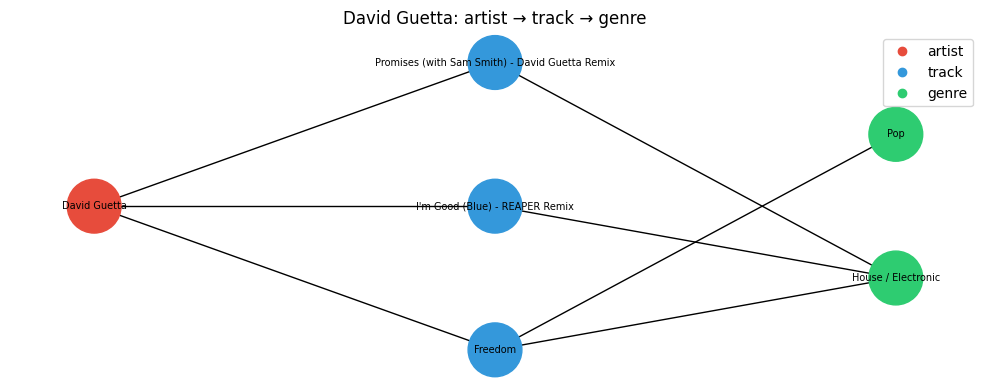

In [31]:
import matplotlib.pyplot as plt

artist = "David Guetta"
tracks = [n for n in G.neighbors(artist) if G.nodes[n]["type"] == "track"][:3]
genres = list(
    {g for t in tracks for g in G.neighbors(t) if G.nodes[g]["type"] == "genre"}
)

subgraph = G.subgraph([artist] + tracks + genres)

color_map = {"artist": "#e74c3c", "track": "#3498db", "genre": "#2ecc71"}
colors = [color_map[G.nodes[n]["type"]] for n in subgraph]

# Layout: artist left, tracks center, genres right
pos = {artist: (0, 0)}
for i, t in enumerate(tracks):
    pos[t] = (1.5, (i - (len(tracks) - 1) / 2) * 1.2)
for i, g in enumerate(genres):
    pos[g] = (3, (i - (len(genres) - 1) / 2) * 1.2)

fig, ax = plt.subplots(figsize=(10, 4))
nx.draw(
    subgraph,
    pos,
    labels={n: n for n in subgraph},
    node_color=colors,
    node_size=1500,
    font_size=7,
    ax=ax,
)
for label, color in color_map.items():
    ax.plot([], [], "o", color=color, label=label)
ax.legend(loc="upper right")
ax.set_title(f"{artist}: artist → track → genre")
plt.tight_layout()
plt.show()